# Imports & Helper Functions

In [126]:
import cv2
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np

from sklearn.cluster import KMeans

# helper function to easily plot + save images at the same time - useful for debugging
def imshow(image, name="image.png", plot=True, write=True, cmap="gist_gray"):
    if write:
        cv2.imwrite(name, image)
    if plot:
        plt.figure(figsize=(9, 9))
        plt.imshow(image, cmap=cmap)
        plt.axis('off')  

# Identifying the Canvas
- In order to extract the canvas from a screenshot of the GUI canny edge detection can be used to segment large enclosed shapes. 

- We can follow the assumption that the contour with the largest enclosed area within a design app screenshot is the canvas.

- Sometimes the canvas will intersect with the edge of the screenshot, which means the edge of the canvas will not be detected - to combat this we can add a border or padding to the image and then later remove it.

- The border colour is chosen based on whether the GUI is in light mode or dark mode
These assumptions can be made:
```
if the GUI is in light mode this usually means the canvas colour is dark
if the GUI is in dark mode this usally means the canvas colour is white
```

- Once edges have been detected we can use `cv2.findContours` to find contours and then sort them in terms of area to find the largest enclosed contour

Resources:
https://www.geeksforgeeks.org/python/adding-borders-to-the-images-using-python-opencv/

Extension: Ideally I would want to find an algorithm to automatically identify whether a black or white border is needed to support edge detection i.e. working out whether the canvas is white or dark. An initial idea was to use the most common pixel colour to make a best guess. You could validate this by checking the canvas occupies a certain ratio of the screen.

In [127]:
def find_canvas(image, light_mode=True):
    if light_mode:
        val = 255 # border = white
    else:
        val = 0 # border = black
        
    pad = 10
    
    bordered_frame = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=[val, val, val])
    
    gray= cv2.cvtColor(bordered_frame,cv2.COLOR_BGR2GRAY)
    
    ret,thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    
    edges = cv2.Canny(thresh, 0, 200)
    # imshow(edges, write=False) # optional code to show inbetween step for debugging
    
    contours, hierarchy= cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    sorted_contours= sorted(contours, key=cv2.contourArea, reverse= True) # find largest contour area
    canvas_contour = sorted_contours[0] # the largest contour area will usually be the canvas; following assumptions laid out above
    
    return canvas_contour - pad # remove border from contours

## Testing with Figma

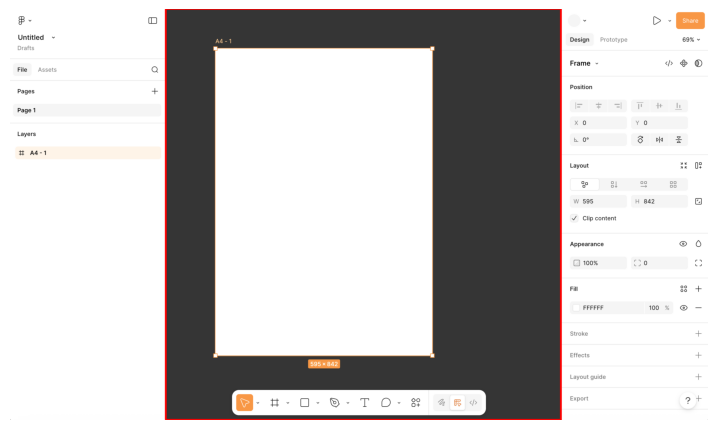

In [128]:
image = cv2.imread('sample-data/figma.png')
canvas = find_canvas(image, light_mode=True)
cv2.drawContours(image, canvas, -1, (255,0,0),5)
imshow(image, write=False)

# Testing for Illustrator Including Canvas Occlusion

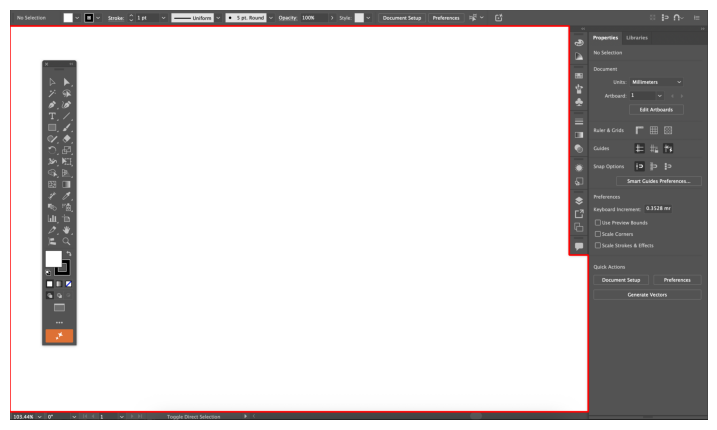

In [129]:
image = cv2.imread('sample-data/illustrator-1.png')
canvas = find_canvas(image, light_mode=False)
cv2.drawContours(image, canvas, -1, (255,0,0),5)
imshow(image, write=False)

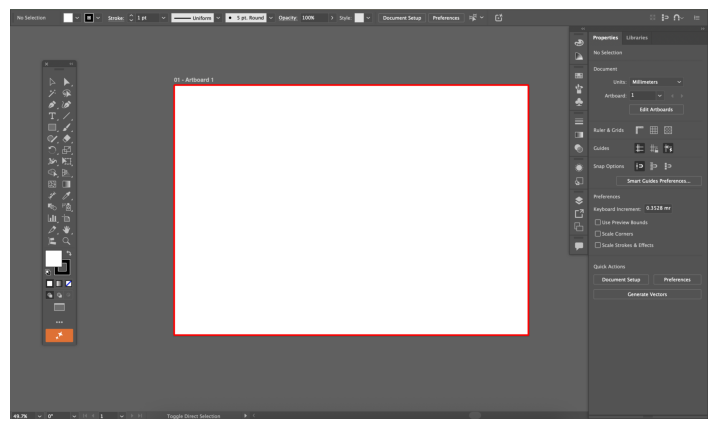

In [130]:
image = cv2.imread('sample-data/illustrator-2.png')
canvas = find_canvas(image, light_mode=False)
cv2.drawContours(image, canvas, -1, (255,0,0),5)
imshow(image, write=False)

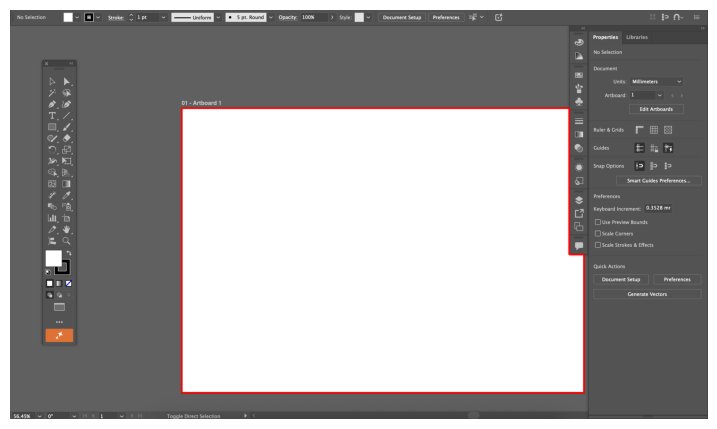

In [131]:
image = cv2.imread('sample-data/illustrator-3.png')
canvas = find_canvas(image, light_mode=False)
cv2.drawContours(image, canvas, -1, (255,0,0),5)
imshow(image, write=False)

# Extracting GUI icons

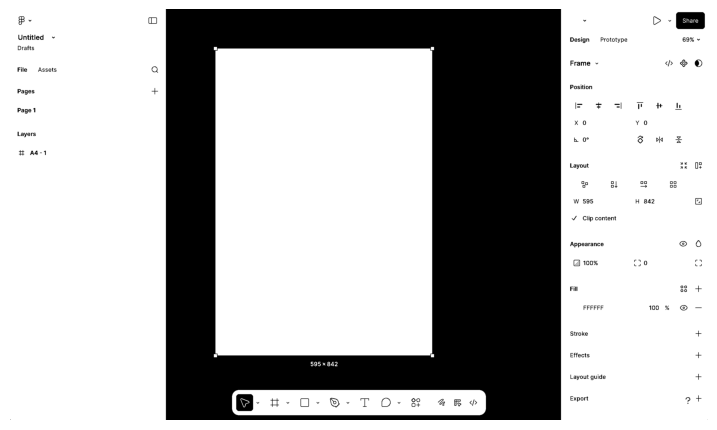

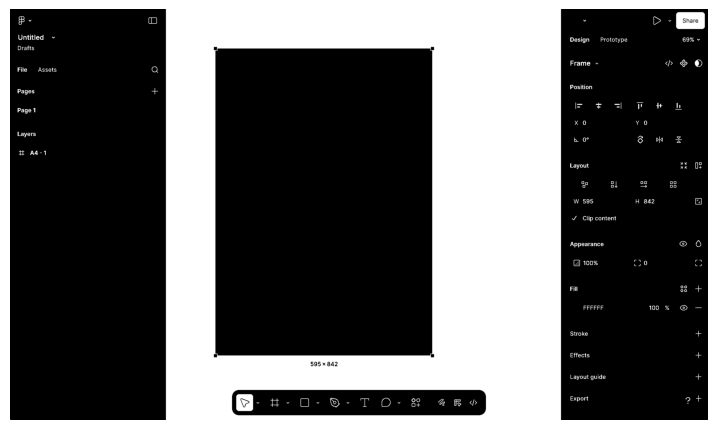

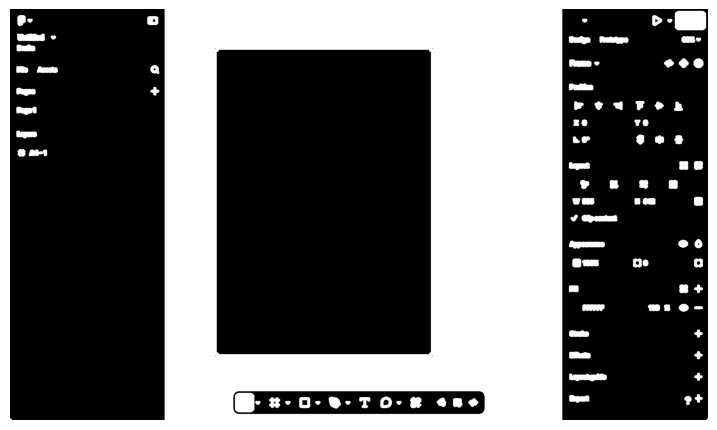

In [132]:
img = cv2.imread("sample-data/figma.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ret, thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

ret, thresh = cv2.threshold(gray, 190, 255, cv2.THRESH_BINARY)
imshow(thresh, write=False)

inverted_image = cv2.bitwise_not(thresh)
imshow(inverted_image, write=False)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(11,11))
dilated = cv2.dilate(inverted_image,kernel,iterations = 1)
imshow(dilated, write=False)


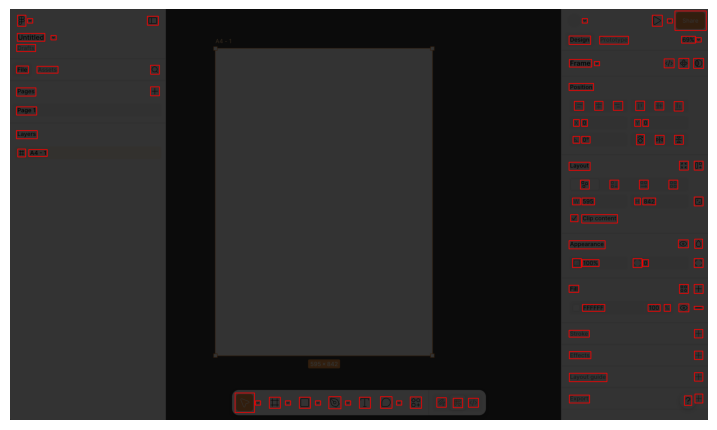

In [133]:
analysis = cv2.connectedComponentsWithStats(dilated, 4, cv2.CV_32S) # what is CV_32S?

(totalLabels, label_ids, stats, centroids) = analysis

w = img.shape[0]
h = img.shape[1]

overlay = img.copy() # crete an overlay to place over the image
cv2.rectangle(overlay, (0, 0), (h, w), (0, 0, 0), -1) # convert to a black overlay

alpha = 0.8 
shaded = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0) # place shade over the original image
bounding_boxes = shaded.copy()

centres_dataset = []

for i in range(1, totalLabels):
    area = stats[i, cv2.CC_STAT_AREA]  

    if (area > 200) and (area < 9000):
        
        (cX, cY) = centroids[i]
        
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        # area = stats[i, cv2.CC_STAT_AREA]
            
        cv2.rectangle(bounding_boxes, (x, y), (x+w, y+h), (255, 0, 0), 2)
        cropped_im = inverted_image[y:y+h, x:x+w]
        cv2.imwrite(f"./icons/icon-{i}.png", cropped_im) # save icon to a collection of icons for further analysis
        
        centres_dataset.append([cX, cY])
        
        
imshow(bounding_boxes, write=False)

# Clustering Icons 

In [134]:
kmeans = KMeans(
    init="random",
    n_clusters=3,
    n_init=10,
    max_iter=300,
    random_state=42
)

kmeans.fit(centres_dataset)

,n_clusters,3
,init,'random'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [135]:
kmeans.cluster_centers_

array([[1358.54219464, 1492.32238745],
       [2383.7103657 ,  675.08149091],
       [ 171.80668687,  250.61596248]])

In [136]:
kmeans.labels_

array([1, 2, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 2,
       1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

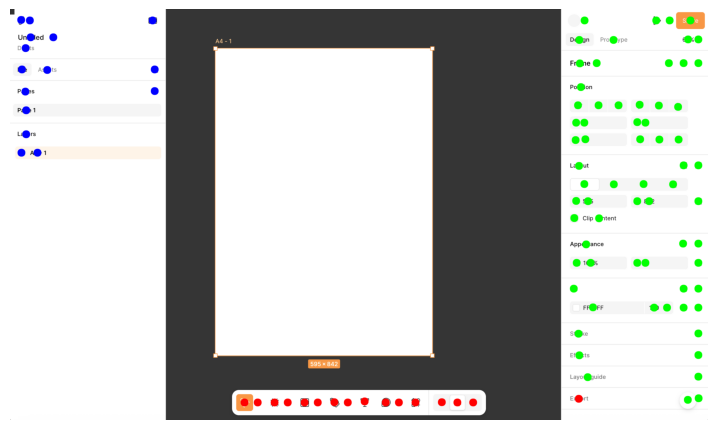

In [ ]:
overlay = img.copy() # crete an overlay to place over the image
cv2.rectangle(overlay, (0, 0), (h, w), (0, 0, 0), -1) # convert to a black overlay

w = img.shape[0]
h = img.shape[1]

alpha = 0.8 
shaded = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0) # place shade over the original image
cluster_view = shaded.copy()

c0x_min = w
c0x_max = 0
c0y_min = h
c0y_max = 0

c1x_min = w
c1x_max = 0
c1y_min = h
c1y_max = 0

c2x_min = w
c2x_max = 0
c2y_min = h
c2y_max = 0

for idx, p in enumerate(centres_dataset):
    x = int(p[0])
    y = int(p[1])
    
    cluster = kmeans.labels_[idx]
    if cluster == 0:
        rgb = (255,0,0)
        
        if x > c0x_max:
            c0x_max = x
        if x < c0x_min:
            c0x_min = x
            
        if y > c0y_max:
            c0y_max = y
        if y < c0y_min:
            c0y_min = y
        
    elif cluster == 1:
        rgb = (0,255,0)
        
        if x > c1x_max:
            c1x_max = x
        if x < c1x_min:
            c1x_min = x
            
        if y > c1y_max:
            c1y_max = y
        if y < c1y_min:
            c1y_min = y
         
    elif cluster == 2:
        rgb = (0,0,255)
        
        if x > c2x_max:
            c2x_max = x
        if x < c2x_min:
            c2x_min = x
            
        if y > c2y_max:
            c2y_max = y
        if y < c2y_min:
            c2y_min = y
        
    else:
        rgb = (0,0,0)
    
    cv2.circle(cluster_view,(x,y), 15, rgb, -1)
    
imshow(cluster_view)


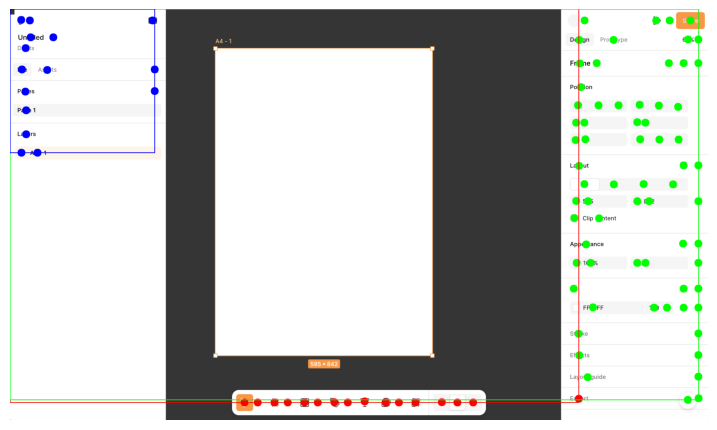

In [138]:
# draw the bounding boxes for each cluster

cv2.rectangle(cluster_view, (c0x_min, c0y_min), (c0x_max , c0y_max ), (255, 0, 0), 2)
cv2.rectangle(cluster_view, (c1x_min, c1y_min), (c1x_max , c1y_max ), (0, 255, 0), 2)
cv2.rectangle(cluster_view, (c2x_min, c2y_min), (c2x_max , c2y_max ), (0, 0, 255), 2)
imshow(cluster_view)

# Trying out further segmentation

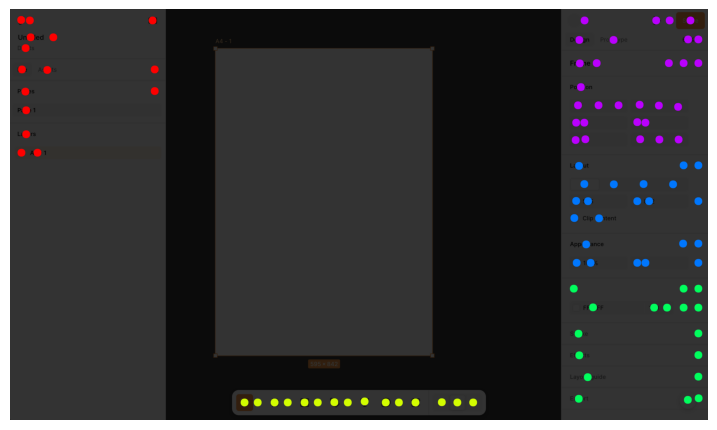

In [139]:
n_clusters = 5

kmeans = KMeans(
    init="random",
    n_clusters=n_clusters,
    n_init=10,
    max_iter=300,
    random_state=42
)

kmeans.fit(centres_dataset)

w = img.shape[0]
h = img.shape[1]

overlay = img.copy() # crete an overlay to place over the image
cv2.rectangle(overlay, (0, 0), (h, w), (0, 0, 0), -1) # convert to a black overlay

alpha = 0.8 
shaded = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0) # place shade over the original image
cluster_view = shaded.copy()

for idx, p in enumerate(centres_dataset):
    x = int(p[0])
    y = int(p[1])
    
    cluster = kmeans.labels_[idx]
    
    h = (356/n_clusters) * cluster
    
    hls = (h, 50, 100)
    hls_conv = (hls[0]/2, hls[1]*2.55, hls[2]*2.55)
    rgb = cv2.cvtColor(np.uint8([[hls_conv]]), cv2.COLOR_HLS2RGB)[0][0]
    # https://stackoverflow.com/questions/66920286/opencv-converts-hsl-to-rgb (how to do colour conversions)
    
    cv2.circle(cluster_view,(x,y), 15, (int(rgb[0]), int(rgb[1]), int(rgb[2])), -1)
    
imshow(cluster_view)

# Labelling/Matching GUI icons using SIFT

# Labelling/Matching GUI icons using CNN Features

# Labelling/Matching GUI icons using CLIP